# Análisis Exploratorio de Datos (EDA) - Churn de Clientes

Este notebook realiza un Análisis Exploratorio de Datos completo sobre el conjunto de datos de Telco Customer Churn. El objetivo es comprender las características, identificar los factores clave de la pérdida de clientes (churn) y preparar la información para el desarrollo del modelo.

## Descripción Detallada de las Características (Features):
---
### 1. Información Demográfica de los Clientes
- **customerID**: Identificador único y exclusivo de cada cliente.
- **gender**: Género del cliente (`Male` / `Female`).
- **SeniorCitizen**: Indica si el cliente es una persona mayor/jubilada (`1`: Sí, `0`: No).
- **Partner**: Indica si el cliente tiene pareja (`Yes` / `No`).
- **Dependents**: Indica si el cliente tiene personas económicamente a su cargo (`Yes` / `No`).

### 2. Servicios Contratados por el Cliente
- **tenure**: Antigüedad del cliente medida en el número de meses que ha permanecido en la compañía.
- **PhoneService**: Indica si el cliente tiene contratado un servicio de telefonía fija (`Yes` / `No`).
- **MultipleLines**: Especifica si el cliente tiene múltiples líneas telefónicas contratadas (`Yes`, `No`, o `No phone service` si no tiene teléfono).
- **InternetService**: Proveedor del servicio de conexión a Internet del cliente (`DSL`, `Fiber optic`, o `No` si no tiene servicio contratado).
- **OnlineSecurity**: Indica si el cliente dispone del servicio de seguridad en línea adicional (`Yes`, `No`, o `No internet service`).
- **OnlineBackup**: Indica si el cliente dispone de un servicio de copia de seguridad adicional en la nube (`Yes`, `No`, o `No internet service`).
- **DeviceProtection**: Indica si el cliente tiene contratado un plan de protección para sus dispositivos o equipos (`Yes`, `No`, o `No internet service`).
- **TechSupport**: Indica si el cliente cuenta con un servicio de soporte técnico prioritario con tiempos de respuesta más rápidos (`Yes`, `No`, o `No internet service`).
- **StreamingTV**: Indica si el cliente tiene contratado el servicio de streaming de TV con el proveedor (`Yes`, `No`, o `No internet service`).
- **StreamingMovies**: Indica si el cliente tiene contratado el servicio de streaming de películas con el proveedor (`Yes`, `No`, o `No internet service`).

### 3. Información Financiera y de Facturación
- **Contract**: El tipo de contrato actual del cliente según la duración (`Month-to-month` / `One year` / `Two year`).
- **PaperlessBilling**: Indica si el cliente ha optado por recibir la factura de forma digital/sin papel (`Yes` / `No`).
- **PaymentMethod**: Método preferido por el cliente para realizar el pago de sus facturas (`Electronic check`, `Mailed check`, `Bank transfer (automatic)`, `Credit card (automatic)`).
- **MonthlyCharges**: Importe económico cobrado mensualmente al cliente por todos sus servicios activos.
- **TotalCharges**: Suma acumulada de todos los cobros que se le han realizado al cliente a lo largo de su antigüedad.

### 4. Variable Objetivo (Target)
- **Churn**: Indica si el cliente canceló su contrato y abandonó la compañía durante el último mes (`Yes`: abandonó, `No`: continúa activo).

## Imports y configuración de estilo de los gráficos
---

In [14]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# Configurar estilo para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 1. Cargar los datos
---
Cargamos el archivo CSV raw ubicado en `../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv`.

In [20]:
# Cargar el dataset
data_path = os.path.join("..", "data", "raw", "WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = pd.read_csv(data_path)

# Inspección rápida
filas, cols = df.shape
display(HTML(f"<p style='font-size: 16px'><b>Número de filas:</b> {filas} | <b>Número de columnas:</b> {cols}</p>"))
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Inspección inicial y limpieza de datos
Vamos a inspeccionar los tipos de datos, los valores nulos y a corregir cualquier anomalía.

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

Observamos que `TotalCharges` está representado como una columna de tipo `object` (cadena de texto) en lugar de `float64`. Esto suele ocurrir por la presencia de espacios en blanco, lo cual, en el caso de nuestro conjunto de datos, ya ha sido reportado por usuarios en Kaggle. Vamos a inspeccionar esas filas.

In [25]:
# Comprobar valores vacíos o con espacios en TotalCharges
empty_total_charges = df[df['TotalCharges'].str.strip() == '']
display(HTML(f"<p style='font-size: 16px'><b>Número de filas con TotalCharges vacío:</b> {len(empty_total_charges)}</p>"))
empty_total_charges[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,,No
753,0,20.25,,No
936,0,80.85,,No
1082,0,25.75,,No
1340,0,56.05,,No
3331,0,19.85,,No
3826,0,25.35,,No
4380,0,20.00,,No
5218,0,19.70,,No
6670,0,73.35,,No


Todas estas filas vacías tienen una antigüedad (`tenure`) de `0`, lo que significa que son clientes nuevos que aún no han sido facturados. Convertiremos `TotalCharges` a numérico e imputaremos estos valores faltantes con `0` ya que aún no han realizado ningún gasto.

In [26]:
# Convertir TotalCharges to numérico, coaccionando errores a NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')

# Rellenar valores NaN con 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Comprobar valores nulos de nuevo
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## 3. Target Variable Analysis: Distribución de Churn
Veamos la proporción de clientes que han abandonado el servicio.

Recuentos de Churn:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Porcentajes de Churn:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


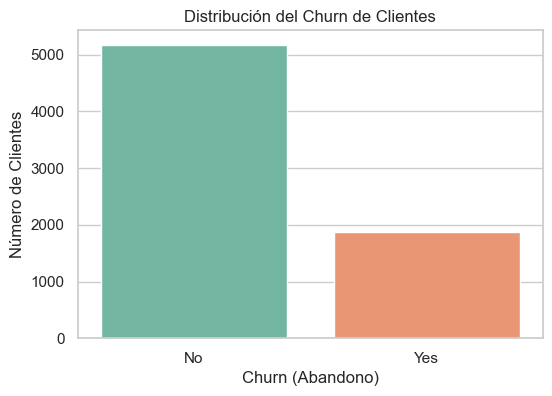

In [30]:
# Calcular tasas de churn
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print("Recuentos de Churn:")
print(churn_counts)
print("\nPorcentajes de Churn:")
print(churn_pct)

# Graficar la distribución de Churn
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', hue='Churn', palette='Set2', legend=False)
plt.title('Distribución del Churn de Clientes')
plt.xlabel('Churn (Abandono)')
plt.ylabel('Número de Clientes')
plt.show()

## 4. Análisis de características numéricas
Analizamos las tres características numéricas principales: `tenure` (antigüedad), `MonthlyCharges` (cargos mensuales) y `TotalCharges` (cargos totales). No tiene sentido incluir `SeniorCitizen` ya que describe un comportamiento booleano.

In [8]:
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


Visualicemos las distribuciones de estas variables numéricas en relación con el Churn.

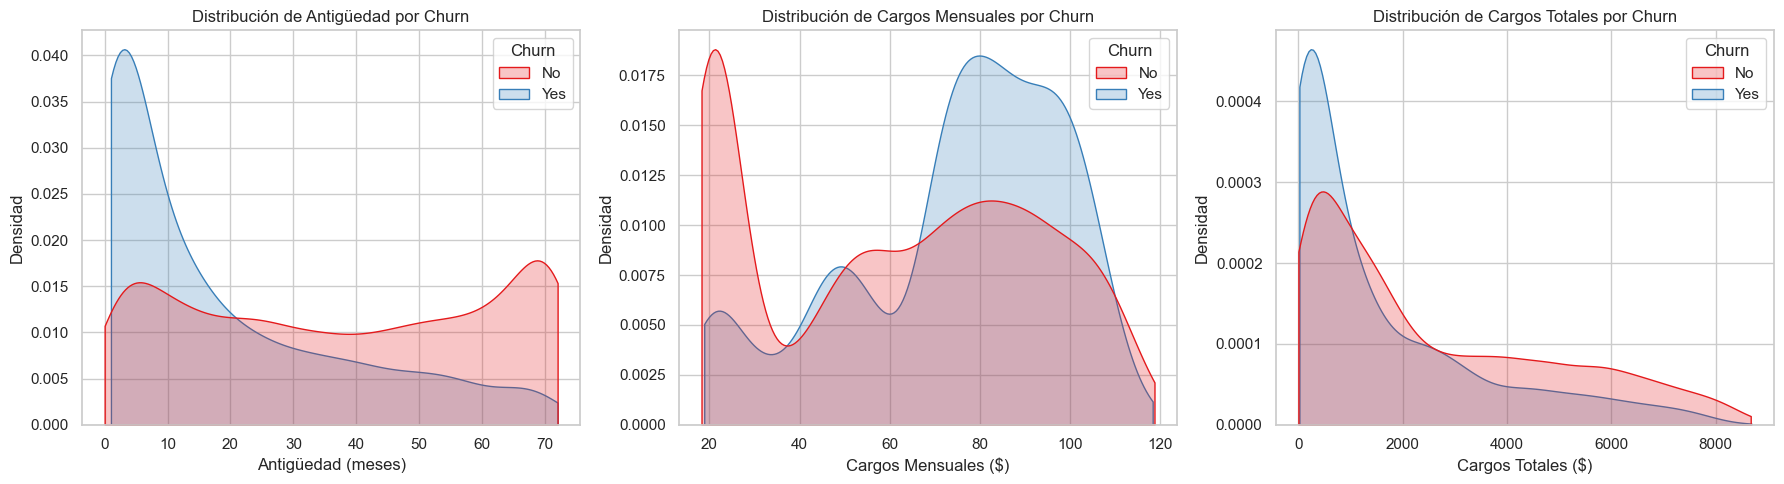

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribución de antigüedad
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, common_norm=False, cut=0, palette='Set1', ax=axes[0])
axes[0].set_title('Distribución de Antigüedad por Churn')
axes[0].set_xlabel('Antigüedad (meses)')
axes[0].set_ylabel('Densidad')

# Distribución de cargos mensuales
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, common_norm=False, cut=0, palette='Set1', ax=axes[1])
axes[1].set_title('Distribución de Cargos Mensuales por Churn')
axes[1].set_xlabel('Cargos Mensuales ($)')
axes[1].set_ylabel('Densidad')

# Distribución de cargos totales
sns.kdeplot(data=df, x='TotalCharges', hue='Churn', fill=True, common_norm=False, cut=0, palette='Set1', ax=axes[2])
axes[2].set_title('Distribución de Cargos Totales por Churn')
axes[2].set_xlabel('Cargos Totales ($)')
axes[2].set_ylabel('Densidad')

plt.tight_layout()
plt.show()

### Observaciones:
- **Antigüedad (Tenure)**: Los clientes que abandonan se concentran en el primer año. Los clientes con mayor antigüedad tienen una probabilidad de abandono mucho menor. La distribución del 'No' tiene forma de valle, debido a que cuando llevan poco tiempo usando el servicio aún no han decidido si mantenerlo o darse de baja y cuando llevan mucho tiempo dados de alta es porque están contentos con el servicio.
- **Cargos Mensuales (Monthly Charges)**: Los cargos mensuales más altos se asocian con mayores tasas de abandono, especialmente en el rango de 70$ a 100$. Los distintos picos que se ven en cada una de las distribuciones de densidad corresponden a los segmentos de clientes del servicio, algunos tienen el plan básico de ~20$, mientras que otros añaden complementos como streaming, servicio técnico, seguridad, etc. que van marcando los diferentes precios que se pueden observar. Este gráfico es muy revelador y pone en evidencia el gran peso que tiene la cuota mensual en la probabilidad de permanencia de un cliente.
- **Cargos Totales (Total Charges)**: Los clientes que abandonaron se concentran en cargos totales bajos, lo que refleja su corta antigüedad. A su vez, los que no abandonan también se concentran ahí, seguramente porque aún no han usado el servicio lo suficiente como para saber si les compensa o no.

Si relacionamos los gráficos 1 y 3, aunque cabría esperar que los clientes con mayor antigüedad acumulasen cargos totales elevados, el gráfico de TotalCharges no refleja esta concentración de forma clara. Esto se explica porque los clientes con mayor permanencia tienden a tener tarifas mensuales más bajas, probablemente asociadas a contratos más económicos o planes básicos que precisamente desincentivan el abandono. Así, un cliente con 70 meses de antigüedad pagando ~20$/mes acumula apenas 1.400$ en total, un valor que queda en la parte baja del eje X. Por el contrario, los clientes con tarifas altas tienden a hacer churn antes de acumular un gasto total significativo. Es por eso que la distribución del 'Sí' entre estos dos gráficos es tan similar pero la del 'No' es tan diferente. El resultado es que TotalCharges combina los efectos de tenure y MonthlyCharges de forma que dificulta su interpretación aislada, lo que sugiere que será una feature menos informativa para el modelo que las dos variables que la componen.

## 5. Análisis de características categóricas
Analicemos cómo influyen las diferentes categorías (datos demográficos, servicios contratados y contratos de facturación) en el Churn.

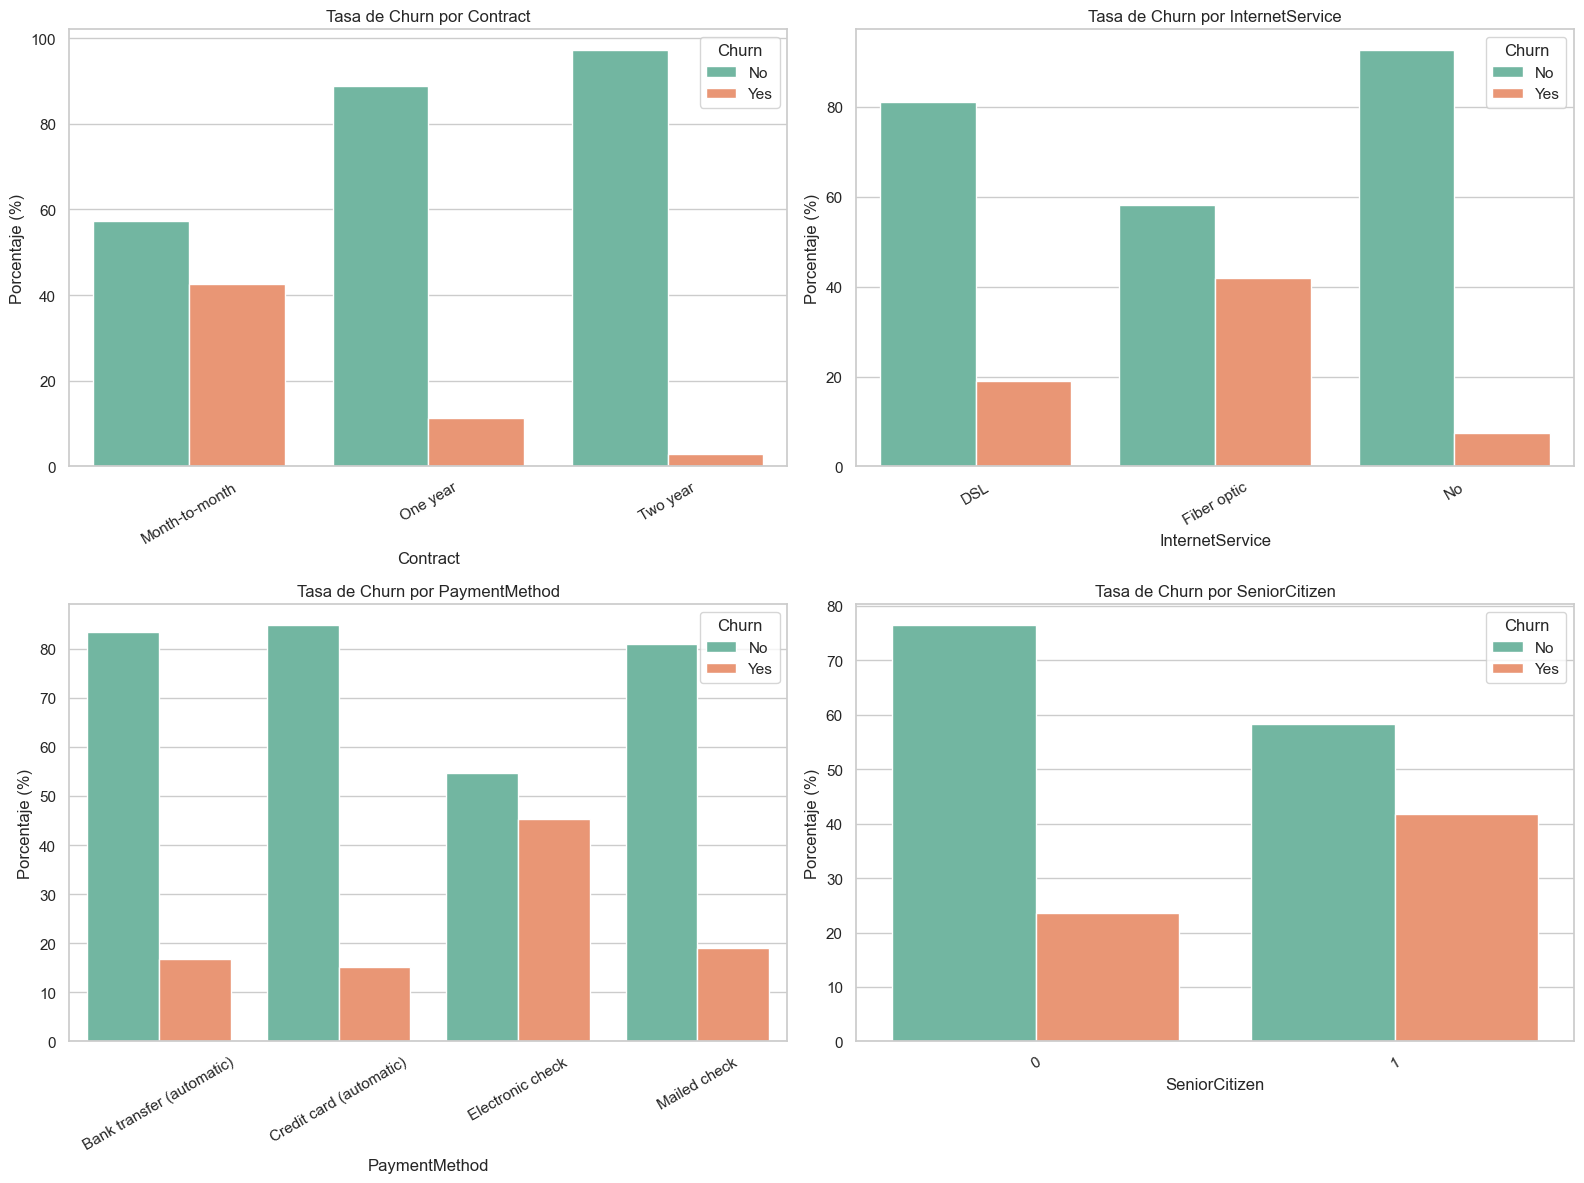

In [41]:
# Función auxiliar para graficar distribuciones categóricas con tasas de churn
def plot_categorical_churn(feature, ax):
    group_df = df.groupby(feature)['Churn'].value_counts(normalize=True).rename('porcentaje').reset_index()
    group_df['porcentaje'] *= 100
    
    sns.barplot(data=group_df, x=feature, y='porcentaje', hue='Churn', palette='Set2', ax=ax)
    ax.set_title(f'Tasa de Churn por {feature}')
    ax.set_ylabel('Porcentaje (%)')
    ax.set_xlabel(feature)
    ax.tick_params(axis='x', rotation=30)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plot_categorical_churn('Contract', axes[0, 0])
plot_categorical_churn('InternetService', axes[0, 1])
plot_categorical_churn('PaymentMethod', axes[1, 0])
plot_categorical_churn('SeniorCitizen', axes[1, 1])

plt.tight_layout()
plt.show()

### Observaciones:
- **Contrato (Contract)**: Los contratos de mes a mes (Month-to-month) tienen una tasa de abandono extremadamente alta en comparación con los contratos de uno o dos años.
- **Servicio de Internet (Internet Service)**: Los clientes con servicio de internet de fibra óptica abandonan a un ritmo mucho mayor que los de DSL o los que no tienen servicio de internet.
- **Método de Pago (Payment Method)**: Los clientes que pagan con cheque electrónico (Electronic check) abandonan significativamente más que los que usan otros métodos automáticos o cheque por correo.
- **Ciudadanos Mayores (Senior Citizens)**: Las personas mayores (valor 1) tienen una tasa de abandono más alta que los no mayores.

## 6. Análisis de correlación
Convertiremos Churn a una variable binaria y calcularemos las correlaciones con las características numéricas.

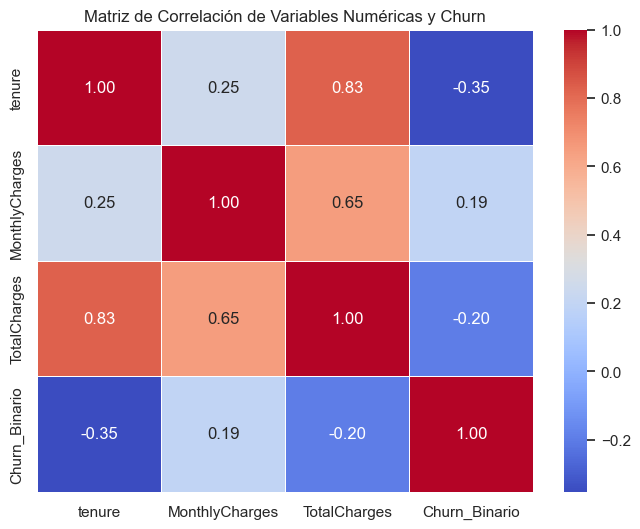

In [42]:
# Convertir Churn a binario (1: Sí, 0: No)
df['Churn_Binario'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Calcular matriz de correlación
corr_matrix = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Binario']].corr()

# Graficar mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas y Churn')
plt.show()

### Observaciones del Análisis de Correlación:

1. **Ausencia de correlación lineal fuerte**: Ninguna de las variables numéricas analizadas presenta una correlación lineal extremadamente alta con la pérdida de clientes (`Churn_Binario`). Esto nos indica que el abandono de los clientes es un fenómeno multifactorial que no depende únicamente de una sola métrica.
2. **Relación con la Antigüedad (`tenure` y `TotalCharges`)**:
   - Existe una correlación **negativa** con la antigüedad (`tenure`). A mayor número de meses de permanencia, **menor es la probabilidad de abandono**, lo que refleja el valor de la fidelidad del cliente con el paso del tiempo.
   - De igual forma, mayores cargos acumulados (`TotalCharges`) se asocian con un menor churn, ya que esta variable está directamente ligada a la larga permanencia en la compañía.
3. **Sensibilidad al Precio (`MonthlyCharges`)**:
   - Existe una correlación **positiva** con los cargos mensuales (`MonthlyCharges`). A mayores montos en la factura mensual, **mayor es la probabilidad de abandono**, lo que sugiere que los clientes son sensibles al precio y tienden a marcharse si consideran que la tarifa mensual es demasiado alta.


### Conclusiones clave y resumen:
1. **La antigüedad es clave**: Los nuevos clientes (antigüedad < 12 meses) representan un alto riesgo de abandono. Las estrategias de retención deben enfocarse en los primeros meses.
2. **Tipo de contrato**: Los contratos mes a mes son extremadamente propensos al abandono. Ofrecer incentivos para migrar a contratos anuales podría reducir el churn drásticamente.
3. **Cargos elevados y fibra óptica**: Cargos mensuales altos y la fibra óptica se correlacionan con mayor abandono. Esto puede indicar insatisfacción con la relación calidad-precio o problemas de servicio.
4. **Método de pago**: El cheque electrónico es un indicador muy fuerte de churn. Fomentar la facturación automática (tarjeta de crédito o transferencia bancaria) podría mejorar la fidelidad del cliente.